# Solar Simulation — Baseline Walkthrough

This notebook demonstrates all functions implemented so far across Epic 1:

| Story | Module | Functions |
|---|---|---|
| 1.2 | `solar.data.loader` | `expand_slp`, `enforce_timezone_bounds`, `save_to_parquet` |
| 1.3 | `solar.simulation` | `run_simulation` |
| 1.3 | `solar.config` | `SimulationConfig` |

This notebook has been updated to use the **real data** generated for the Tore, Kalix 2025 simulation.

## 0  — Environment check

In [ ]:
import sys
print(f"Python: {sys.version}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
print(f"numpy  {np.__version__}")
print(f"pandas {pd.__version__}")

# Confirm the solar package is importable
from solar.config import SimulationConfig
from solar.data.loader import expand_slp, enforce_timezone_bounds, save_to_parquet
from solar.simulation import run_simulation
print("\n✅ All solar modules imported successfully")

Python: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
numpy  2.4.4
pandas 3.0.2


ModuleNotFoundError: No module named 'solar'

---
## 1  — Story 1.2: Data Loader

### 1a  `expand_slp` — Monthly kWh → 8760-hour array

Distributes 12 monthly energy totals into hourly slots using a Standard Load Profile weight array.

In [2]:
# Real monthly consumption for Tore, Kalix 2025
MONTHLY_KWH = np.array([
    2060, 1566, 1237,  # Jan Feb Mar
     889,  544,  584,  # Apr May Jun
     630,  650,  446,  # Jul Aug Sep
     306, 1148, 1629,  # Oct Nov Dec
], dtype=float)

print(f"Total annual consumption: {MONTHLY_KWH.sum():,.0f} kWh")

# Flat SLP weights (uniform baseline — each hour equally weighted within its month)
slp_weights = np.ones(8760)
consumption_kwh = expand_slp(MONTHLY_KWH, slp_weights)

print(f"Output shape : {consumption_kwh.shape}")
print(f"Min hourly   : {consumption_kwh.min():.4f} kWh")
print(f"Max hourly   : {consumption_kwh.max():.4f} kWh")
print(f"Annual total : {consumption_kwh.sum():,.1f} kWh  (expected: {MONTHLY_KWH.sum():,.1f})")

Total annual consumption: 11,689 kWh
Output shape : (8760,)
Min hourly   : 0.4107 kWh
Max hourly   : 2.7688 kWh
Annual total : 11,689.0 kWh  (expected: 11,689.0)


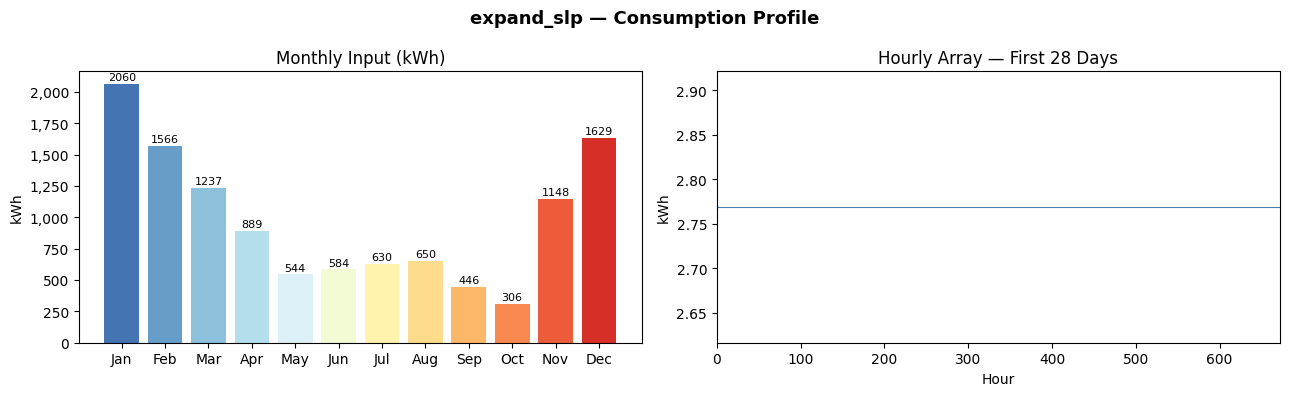

In [3]:
# Plot monthly consumption profile
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('expand_slp — Consumption Profile', fontsize=13, fontweight='bold')

# Monthly bar chart
ax = axes[0]
bars = ax.bar(month_labels, MONTHLY_KWH, color=plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, 12)))
ax.set_title('Monthly Input (kWh)')
ax.set_ylabel('kWh')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, MONTHLY_KWH):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15, f'{val:.0f}',
            ha='center', va='bottom', fontsize=8)

# Hourly time-series (first 4 weeks)
ax = axes[1]
ax.plot(consumption_kwh[:24*28], linewidth=0.8, color='steelblue')
ax.set_title('Hourly Array — First 28 Days')
ax.set_xlabel('Hour')
ax.set_ylabel('kWh')
ax.set_xlim(0, 24*28)

plt.tight_layout()
plt.show()

### 1b  `enforce_timezone_bounds` — Timezone enforcement + 8760-row guarantee

In [4]:
import pathlib
RAW_DIR = pathlib.Path("../data/raw")

# Load the actual raw SE1 2025 spot prices we downloaded (which are in UTC!)
raw_spot_df = pd.read_csv(RAW_DIR / "spot_prices_se1_2025.csv", parse_dates=["time_start"])
raw_spot_df = raw_spot_df.rename(columns={"SEK_per_kWh": "spot_prices"})
raw_spot_df = raw_spot_df.set_index("time_start")
raw_spot_df = raw_spot_df.dropna(subset=["spot_prices"]).iloc[:8760]

print(f"Input  : tz={raw_spot_df.index.tz}, rows={len(raw_spot_df)}")

import warnings
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    spot_df_sthlm = enforce_timezone_bounds(raw_spot_df)

print(f"Output : tz={spot_df_sthlm.index.tz}, rows={len(spot_df_sthlm)}")
if caught:
    for w in caught:
        print(f"⚠️  Warning raised: {w.message}")
else:
    print("No warnings (already Stockholm tz or naive)")

Input  : tz=UTC, rows=8760
Output : tz=Europe/Stockholm, rows=8760
⚠️  Warning raised: Input timezone is 'UTC', converting to 'Europe/Stockholm'. Verify alignment with other input arrays.


---
## 2  — Story 1.3: Baseline Simulation

### 2a  `SimulationConfig` — Dataclass inspection

In [5]:
PROCESSED_DIR = pathlib.Path("../data/processed")
import dataclasses

# Baseline config: 0 PV, 0 Battery
baseline_cfg = SimulationConfig(battery_capacity_kwh=0.0)
print("Baseline config:")
for f in dataclasses.fields(baseline_cfg):
    print(f"  {f.name:25s} = {getattr(baseline_cfg, f.name)}")

# Timeseries config
ts_cfg = SimulationConfig(battery_capacity_kwh=0.0, return_timeseries=True)
print(f"\nTimeseries config return_timeseries = {ts_cfg.return_timeseries}")

# Demonstrate NotImplementedError guard
try:
    run_simulation(SimulationConfig(battery_capacity_kwh=10.0), str(PROCESSED_DIR), "2025")
except NotImplementedError as e:
    print(f"\n✅ NotImplementedError correctly raised for non-zero capacity:\n   {e}")

Baseline config:
  
  battery_capacity_kwh      = 0.0
  return_timeseries         = False
  grid_transfer_fee_sek     = 0.18
  energy_tax_sek            = 0.264
  vat_rate                  = 0.25
  utility_sell_compensation = 0.05
  tax_credit_rate           = 0.6
  aggregator_fee_pct        = 0.2
  aggregator_flat_fee_yearly = 0.0

Timeseries config return_timeseries = True

✅ NotImplementedError correctly raised for non-zero capacity:
   PV/Battery not yet implemented — set redundant=0 and battery_capacity_kwh=0 for the baseline run.


### 2b  `run_simulation` — Scalar metrics (return_timeseries=False)

In [6]:
# Run simulation for analytics (return_timeseries=True)
metrics, ts_df = run_simulation(ts_cfg, str(PROCESSED_DIR), "2025")

print("📊 Baseline Metrics (Tore, SE1, 2025)\n" + "─" * 40)
for key, value in metrics.items():
    print(f"  {key:35s}: {value:,.2f} SEK")

# Sanity check: verify timeseries aggregates to the same total
ts_total = ts_df["hourly_spend"].sum()
assert abs(metrics["total_money_spent"] - ts_total) < 1e-6
print(f"\n✅ Timeseries Integrity: {ts_total:,.4f} SEK (matches total_money_spent)")
print(f"   DataFrame Schema: {list(ts_df.columns)}")

📊 Baseline Metrics (Tore, SE1, 2025)
────────────────────────────────────────
  total_money_spent                  : 8,709.94 SEK
  total_money_earned_spot_sek        : 0.00 SEK
  total_tax_credit_sek               : 0.00 SEK
  net_electricity_cost_sek           : 8,709.94 SEK

✅ Timeseries Integrity: 8,709.9427 SEK (matches total_money_spent)
   DataFrame Schema: ['consumption', 'grid_buy', 'spot_prices', 'hourly_spend', 'hourly_earn_spot']


### 2c  `run_simulation` — With timeseries (return_timeseries=True)

In [7]:
metrics_ts, ts_df = run_simulation(ts_cfg, str(PROCESSED_DIR), "2025")

print(f"Timeseries DataFrame shape  : {ts_df.shape}")
print(f"Columns                     : {list(ts_df.columns)}")
print(f"\nFirst 5 rows:")
print(ts_df.head().to_string())

# At baseline: grid_buy should equal consumption exactly
match = np.allclose(ts_df['grid_buy'].values, ts_df['consumption'].values)
print(f"\n✅ grid_buy == consumption (0-baseline invariant): {match}")

Timeseries DataFrame shape  : (8760, 5)
Columns                     : ['consumption', 'grid_buy', 'spot_prices', 'hourly_spend', 'hourly_earn_spot']

First 5 rows:
   consumption  grid_buy  spot_prices  hourly_spend  hourly_earn_spot
0     2.768817  2.768817      0.05588      1.730095               0.0
1     2.768817  2.768817      0.04546      1.694032               0.0
2     2.768817  2.768817      0.04374      1.688079               0.0
3     2.768817  2.768817      0.03996      1.674996               0.0
4     2.768817  2.768817      0.03962      1.673819               0.0

✅ grid_buy == consumption (0-baseline invariant): True


### 2d  Visualise the baseline results

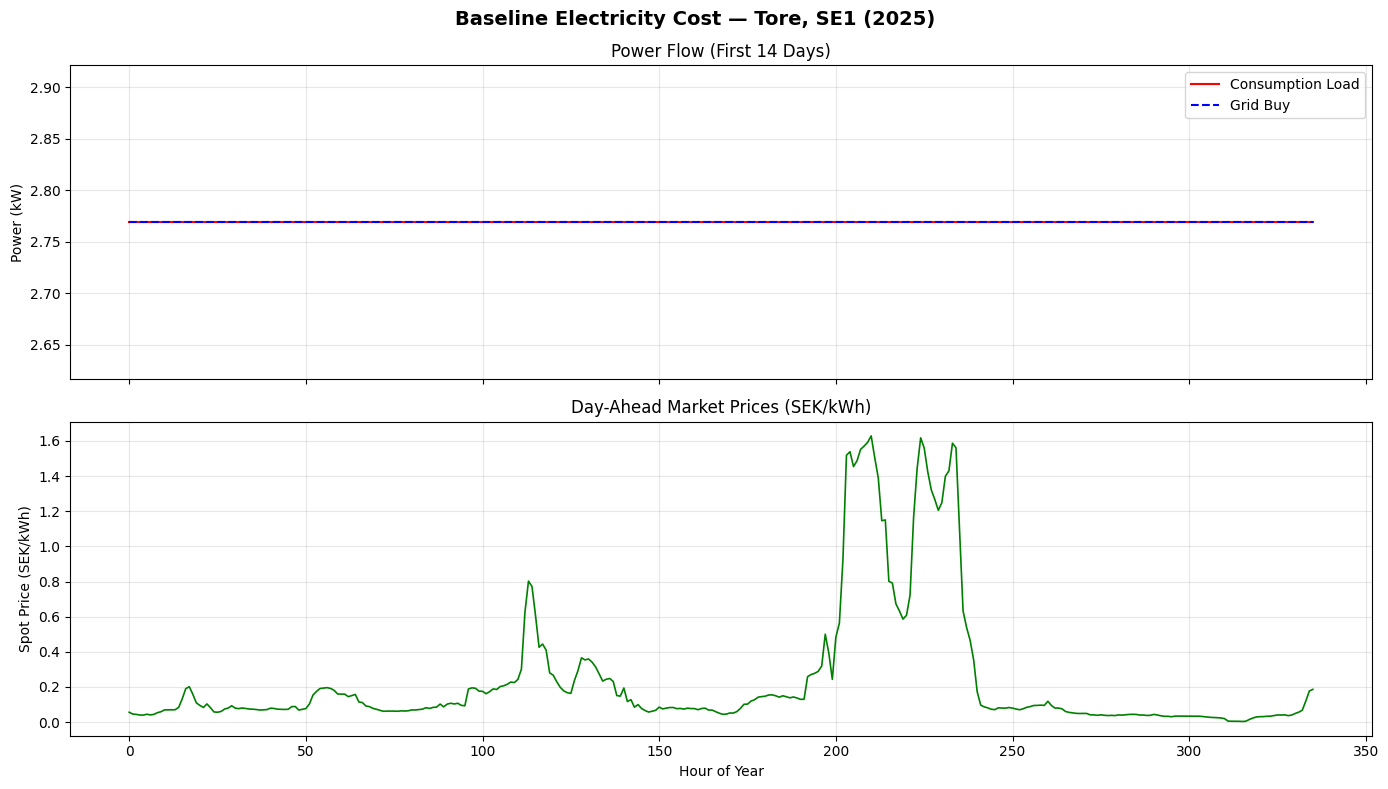

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Baseline Electricity Cost — Tore, SE1 (2025)', fontsize=14, fontweight='bold')

# The first two weeks of the year (24 hours * 14 days = 336 hours)
hours_to_plot = 336
x_axis = np.arange(hours_to_plot)

ax = axes[0]
ax.plot(x_axis, ts_df['consumption'].iloc[:hours_to_plot], label='Consumption Load', color='red', linewidth=1.5)
ax.plot(x_axis, ts_df['grid_buy'].iloc[:hours_to_plot], label='Grid Buy', color='blue', linestyle='--', linewidth=1.5)
ax.set_ylabel('Power (kW)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
ax.set_title('Power Flow (First 14 Days)')

ax2 = axes[1]
ax2.plot(x_axis, ts_df['spot_prices'].iloc[:hours_to_plot], color='green', linewidth=1.2)
ax2.set_ylabel('Spot Price (SEK/kWh)')
ax2.set_xlabel('Hour of Year')
ax2.grid(alpha=0.3)
ax2.set_title('Day-Ahead Market Prices (SEK/kWh)')

plt.tight_layout()
plt.show()

---
## 3  — Monthly Financial Analysis

Since we now have the `hourly_spend` returned in the `ts_df`, we can easily aggregate by month and visualize the seasonality of the electricity costs.

C:\Users\Serge\AppData\Local\Temp\ipykernel_15764\645510817.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_spend = ts_df["hourly_spend"].resample("M").sum()


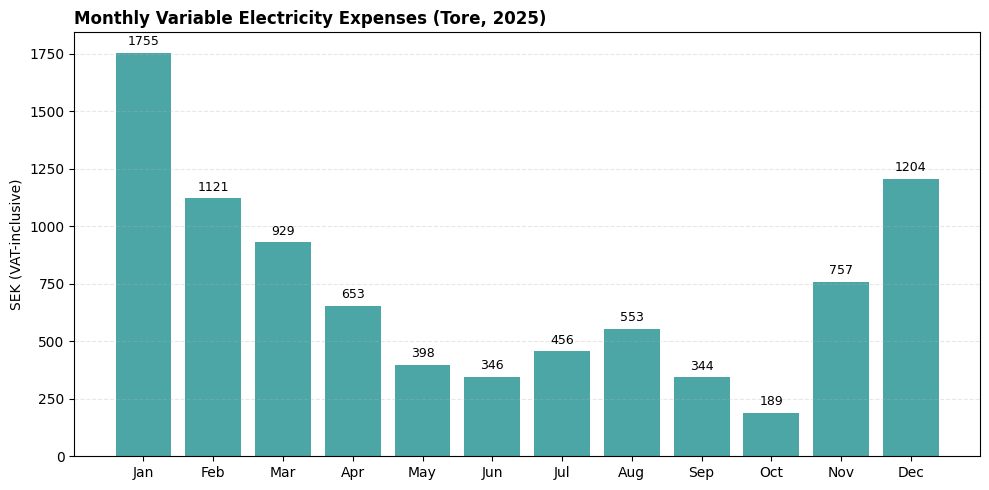

Total Variable Cost: 8,709.94 SEK


In [9]:
# 1. Assign a 2025 hourly datetime index
time_index = pd.date_range(start="2025-01-01 00:00:00", periods=8760, freq="h", tz="Europe/Stockholm")
ts_df.index = time_index

# 2. Resample to Monthly sums
monthly_spend = ts_df["hourly_spend"].resample("M").sum()
months = [d.strftime('%b') for d in monthly_spend.index]

# 3. Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(months, monthly_spend, color="teal", alpha=0.7)
plt.title("Monthly Variable Electricity Expenses (Tore, 2025)", loc="left", fontweight="bold")
plt.ylabel("SEK (VAT-inclusive)")
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, f"{int(yval)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Total Variable Cost: {monthly_spend.sum():,.2f} SEK")